# Demo: Water Rescue

```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```


## Motivation

- First responders are increasingly using drones for assistance in emergency water rescue missions

- The water rescue model provides a simple systems model of a beach environment we can use to understand how the presence of drone effects different scenarios


## Model Structure 

The water rescue model has two main agent types:

- `Drone`, follows a patrol path and looks for swimmers in distress in the radius of their vision and goes to drop a buoy after sending an alert to first responders
- `Responder`, which looks for swimmers in distress in their field of vision and goes off to rescue them when they spot one, or they receive an alert from a drone that spots one

These agents interact via the flow:

- `BeachEnvironment`, a `CommsFlow` tracking the map and victim states

## Environment


In this environment, responders cycle between `standby`, `rescue`, modes while drones cycle between `patrol` and `rescue` modes

In [1]:
from fmdtools_examples.airspacelib.water_rescue.model_environment import BeachMap, sim_properties
bm = BeachMap()
sim_properties

{'peripheral': True, 'paracentral': True}
[]


{'beach': {'color': 'sandybrown'},
 'water': {'color': 'steelblue'},
 'person_to_rescue': {'color': 'red'},
 'base': {'color': 'black'},
 'with_buoy': {'color': 'yellow'},
 'rescued': {'color': 'green'},
 'dead': {'color': 'purple'}}

In [2]:
from fmdtools_examples.airspacelib.water_rescue.model_environment import BeachMap, BeachEnvironment, sim_properties
from fmdtools_examples.airspacelib.water_rescue.model_drone import BeachAircraft
import fmdtools.sim.propagate as prop

be = BeachEnvironment()
drone = BeachAircraft()

result, hist = prop.nominal(drone)

> **Note:** `draw_graphviz()` in the following cell requires the Graphviz software to be installed on your system (not just the `graphviz` Python package). If you get an `ExecutableNotFound: failed to execute PosixPath('dot')` error, install it via:
> - **macOS:** `brew install graphviz`
> - **Ubuntu/Debian:** `sudo apt-get install graphviz`
> - **Windows:** `winget install graphviz` or download from [graphviz.org/download](https://graphviz.org/download/)
>
> After installing, restart your terminal/IDE so it picks up the updated PATH.

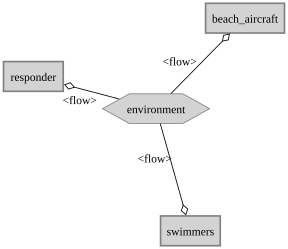

In [3]:
from fmdtools_examples.airspacelib.water_rescue.model_main import Beach
mdl= Beach()
mg = mdl.as_modelgraph()
# fig, ax = mg.draw()
fig = mg.draw_graphviz(size = '4,9', layout="neato", len='1', scale='2')

**Figure 1:** *Function Architecture for Beach*

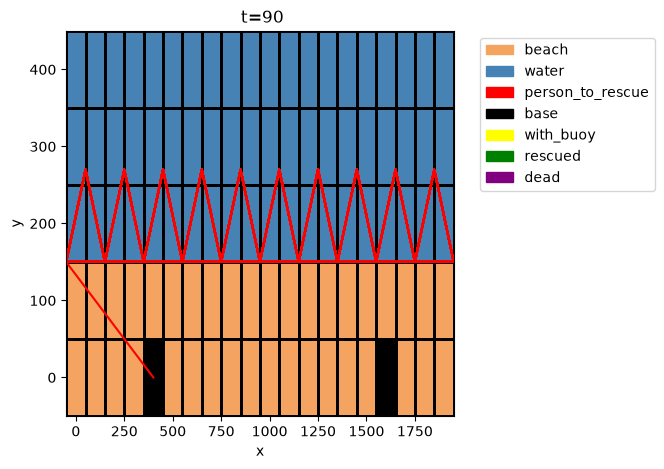

In [4]:
from fmdtools_examples.airspacelib.water_rescue.model_environment import BeachMap, BeachEnvironment, sim_properties
from fmdtools_examples.airspacelib.water_rescue.model_drone import BeachAircraft
import fmdtools.sim.propagate as prop

be = BeachEnvironment()
drone = BeachAircraft(environment=be, track="all",
                       sp={'end_time': 10000, 'dt': 1.0})

result, hist = prop.nominal(drone, protect=False)

fig, ax = drone.environment.c.show_from(
    90, hist.environment.c, properties=sim_properties
)
hist.plot_trajectory('s.x', 's.y', fig=fig, ax=ax, mark_time=False, time_ticks=200.0, color='red')

**Figure 2:** *A basic zigzag drone patrol path over the shoreline completed to its fullest without detecting a swimmer in distress.*

in_range: False, pt: None
timer: 100.0, person_to_rescue: False
in_range: False, pt: None
timer: 99.0, person_to_rescue: False
in_range: False, pt: None
timer: 98.0, person_to_rescue: False
in_range: False, pt: None
timer: 97.0, person_to_rescue: False
in_range: False, pt: None
timer: 96.0, person_to_rescue: False
in_range: False, pt: None
timer: 95.0, person_to_rescue: False
in_range: False, pt: None
timer: 94.0, person_to_rescue: False
in_range: False, pt: None
timer: 93.0, person_to_rescue: False
in_range: False, pt: None
timer: 92.0, person_to_rescue: False
in_range: False, pt: None
timer: 91.0, person_to_rescue: False
in_range: False, pt: None
timer: 90.0, person_to_rescue: False
in_range: False, pt: None
timer: 89.0, person_to_rescue: False
in_range: False, pt: None
timer: 88.0, person_to_rescue: False
in_range: False, pt: None
timer: 87.0, person_to_rescue: False
in_range: False, pt: None
timer: 86.0, person_to_rescue: False
in_range: False, pt: None
timer: 85.0, person_to_rescu

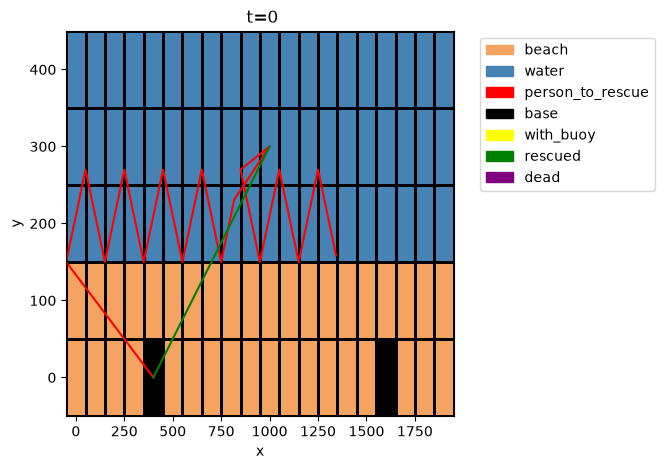

In [5]:
from fmdtools_examples.airspacelib.water_rescue.model_main import Beach
from fmdtools_examples.airspacelib.water_rescue.model_environment import sim_properties
import fmdtools.sim.propagate as prop
mdl = Beach(sp={'end_time': 452, 'dt': 1.0}, track="all")
result, hist = prop.nominal(mdl, protect=False)

fig, ax = mdl.flows['environment'].c.show_from(
    0, hist.flows.environment.c, properties=sim_properties
)
hist.plot_trajectory('fxns.beach_aircraft.s.x', 'fxns.beach_aircraft.s.y',
                     fig=fig, ax=ax, mark_time=False, time_ticks=200.0, color='red')
hist.plot_trajectory('fxns.responder.s.x', 'fxns.responder.s.y',
                     fig=fig, ax=ax, mark_time=False, time_ticks=200.0, color='green')

**Figure 3:** *The paths show the drone delivering a buoy to a swimmmer in distress it encounters on its patrol path, notifying a responder who can reach the swimmer, and returning to its patrol path afterwards*

Drone reached victim at t = 310.0s
Victim fully safe at t = 449.0s
Victim survived


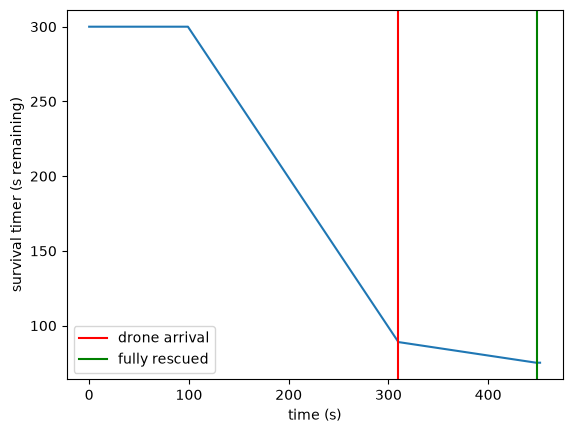

In [6]:
import numpy as np
import matplotlib.pyplot as plt

t_drone = hist.fxns.beach_aircraft.s.time_arrived[-1]
t_safe  = hist.fxns.responder.s.time_rescued[-1]

victim = mdl.flows['environment'].c.p.rescue_locations[0]
ix, iy = mdl.flows['environment'].c.to_index(*victim)

timer = hist.flows.environment.c.survival_timer[:, ix, iy]
died  = hist.flows.environment.c.dead[:, ix, iy]

print(f"Drone reached victim at t = {t_drone}s")
print(f"Victim fully safe at t = {t_safe}s")
if died.any():
    t_death = hist.time[np.argmax(died)]
    print(f"Victim died at t = {t_death}s")
else:
    print("Victim survived")

plt.plot(hist.time, timer)
plt.axvline(t_drone, color='red', label='drone arrival')
plt.axvline(t_safe, color='green', label='fully rescued')
plt.xlabel('time (s)')
plt.ylabel('survival timer (s remaining)')
plt.legend()
plt.show()

**Figure 4:** *The rate of change of the survival timer decreases significantly with the presence of a buoy after delivered by a drone, which allows for a swift rescue by a first responder*

{'peripheral': True, 'paracentral': True}
[]


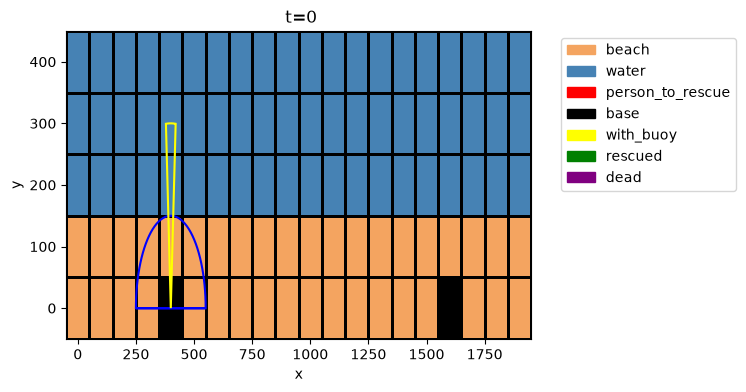

In [7]:
from IPython.display import HTML
import matplotlib


from model_responder import plot_combined_response_from

ani = hist.animate(plot_combined_response_from, mdl=mdl)

**Figure 5:** *Responder's FOV represented by a sweeping cone and static semicircle*

In [8]:
# HTML(ani.to_jshtml())

The animation shows the responder's limited field of vision in cases where a swimmer in distress may be located further away. A drone is able to detect the swimmer and drops a buoy, notifying the responder, who reaches the swimmer in time.

In [9]:
import io
import contextlib
import numpy as np

import fmdtools.sim.propagate as prop
from fmdtools.sim.sample import ParameterDomain, ParameterSample
from fmdtools.analyze.tabulate import NominalEnvelope, Comparison
from fmdtools.define.container.parameter import Parameter

from fmdtools_examples.airspacelib.water_rescue.model_main import Beach
from fmdtools_examples.airspacelib.water_rescue.model_environment import BeachEnvironment, BeachBehavior
from fmdtools_examples.airspacelib.water_rescue.model_responder import Responder
from fmdtools_examples.airspacelib.water_rescue.model_drone import BeachAircraft


def quiet(fn, *a, **k):
    # the model print()s each step; keep the notebook readable
    with contextlib.redirect_stdout(io.StringIO()):
        return fn(*a, **k)

In [10]:
class HazardParam(Parameter):
    victim_x: float = 1000.0        # position along the beach (m)
    victim_y: float = 300.0         # distance offshore (m); water is y >= 200
    distress_onset: float = 100.0   # time (s) the swimmer goes into distress
    with_aircraft: bool = True


class HazardBeach(Beach):
    container_p = HazardParam

    def init_architecture(self, **kwargs):
        vic = (self.p.victim_x, self.p.victim_y)
        self.add_flow("environment", BeachEnvironment,
                      c={'p': {'rescue_locations': (vic,)}})
        # distress onset = initial countdown at the victim's tile
        self.flows['environment'].c.set(vic[0], vic[1], "distress_timer",
                                        self.p.distress_onset)
        self.add_fxn("responder", Responder, "environment")
        self.add_fxn("swimmers", BeachBehavior, "environment")
        if self.p.with_aircraft:
            self.add_fxn("beach_aircraft", BeachAircraft, "environment")

    def classify(self, scen={}, **kwargs):
        # metrics for each parameter-sample run (feeds `res`)
        t_resc = float(self.fxns['responder'].s.time_rescued)
        if self.p.with_aircraft:
            t_drone = float(self.fxns['beach_aircraft'].s.time_arrived)
        else:
            t_drone = 0.0
        rescued = t_resc >= 0
        return {'prob': getattr(scen, 'prob', 1.0),
                'rescued': rescued,
                'rescue_time': t_resc if rescued else np.nan,
                'rescue_delay': (t_resc - self.p.distress_onset) if rescued else np.nan,
                'drone_helped': t_drone >= 0,
                'classification': 'rescued' if rescued else 'not_rescued'}


# the whole sample runs against a single model instance
mdl = HazardBeach(sp={'end_time': 800})
mdl.sp

SimParam(phases=(('na', 0.0, 800),), start_time=0.0, end_time=800.0, track_times=('all',), dt=1.0, units='hr', end_condition='', use_local=True, with_loadings=False, run_stochastic=False, track_pdf=False)

In [11]:
pdA = ParameterDomain(HazardParam)
pdA.add_variables("victim_x", "victim_y",
                  lims={"victim_x": (200.0, 1800.0), "victim_y": (200.0, 400.0)})
pdA.add_constant("distress_onset", 100.0)
pdA

ParameterDomain with:
 - variables: {'victim_x': (200.0, 1800.0), 'victim_y': (200.0, 400.0)}
 - constants: {'distress_onset': 100.0}
 - parameter_initializer: HazardParam

In [12]:
psA = ParameterSample(pdA)
psA.add_variable_ranges(comb_kwargs={'resolutions': {'victim_x': 400.0,
                                                     'victim_y': 100.0}})
print(len(psA.scenarios()), "scenarios")
psA

15 scenarios


ParameterSample of scenarios:
 - rep0_range_0
 - rep0_range_1
 - rep0_range_2
 - rep0_range_3
 - rep0_range_4
 - rep0_range_5
 - rep0_range_6
 - rep0_range_7
 - rep0_range_8
 - rep0_range_9
 - ... (15 total)

In [13]:
resA, histA = quiet(prop.parameter_sample, mdl, psA, showprogress=False)
resA

rep0_range_0.tend.classify.prob: 0.06666666666666667
rep0_range_0.tend.classify.rescued: True
rep0_range_0.tend.classify.rescue_time: 173.0
rep0_range_0.tend.cl                73.0
rep0_range_0.tend.cl                True
rep0_range_0.tend.cl             rescued
rep0_range_1.tend.classify.prob: 0.06666666666666667
rep0_range_1.tend.classify.rescued: True
rep0_range_1.tend.classify.rescue_time: 193.0
rep0_range_1.tend.cl                93.0
rep0_range_1.tend.cl                True
rep0_range_1.tend.cl             rescued
rep0_range_2.tend.classify.prob: 0.06666666666666667
rep0_range_2.tend.classify.rescued: True
rep0_range_2.tend.classify.rescue_time: 243.0
rep0_range_2.tend.cl               143.0
rep0_range_2.tend.cl                True
rep0_range_2.tend.cl             rescued
rep0_range_3.tend.classify.prob: 0.06666666666666667
rep0_range_3.tend.classify.rescued: True
rep0_range_3.tend.classify.rescue_time: 182.0
rep0_range_3.tend.cl                82.0
rep0_range_3.tend.cl          

(<Figure size 600x400 with 1 Axes>,
 <Axes: xlabel='p.victim_x', ylabel='p.victim_y'>)

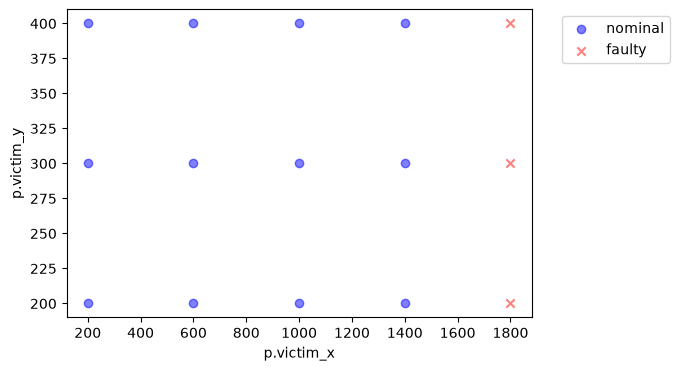

In [14]:
neA = NominalEnvelope(psA, resA, 'rescued', 'p.victim_x', 'p.victim_y',
                      func=lambda x: x == True)
neA.as_plot()

Every far-offshore hazard (`victim_y = 400`) is a coverage gap because
the drone patrols too close to shore to spot them and the responder's cone doesn't reach.

In [15]:
resA.state_probabilities()

{'rescued': 0.7999999999999999, 'not_rescued': 0.2}

Next we sample the space in more detail to see exactly how the drone affects rescue time...

In [16]:
pdB = ParameterDomain(HazardParam)
pdB.add_variables("victim_x", "victim_y",
                  lims={"victim_x": (0.0, 1900.0), "victim_y": (200.0, 400.0)})
pdB.add_constant("distress_onset", 100.0)
pdB

ParameterDomain with:
 - variables: {'victim_x': (0.0, 1900.0), 'victim_y': (200.0, 400.0)}
 - constants: {'distress_onset': 100.0}
 - parameter_initializer: HazardParam

In [17]:
psB = ParameterSample(pdB)
psB.add_variable_ranges(comb_kwargs={'resolutions': {'victim_x': 100.0,
                                                     'victim_y': 100.0}})
print(len(psB.scenarios()), "scenarios")
psB

60 scenarios


ParameterSample of scenarios:
 - rep0_range_0
 - rep0_range_1
 - rep0_range_2
 - rep0_range_3
 - rep0_range_4
 - rep0_range_5
 - rep0_range_6
 - rep0_range_7
 - rep0_range_8
 - rep0_range_9
 - ... (60 total)

In [18]:
resB, histB = quiet(prop.parameter_sample, mdl, psB, showprogress=False)
resB

rep0_range_0.tend.classify.prob: 0.016666666666666666
rep0_range_0.tend.classify.rescued: True
rep0_range_0.tend.classify.rescue_time: 214.0
rep0_range_0.tend.cl               114.0
rep0_range_0.tend.cl                True
rep0_range_0.tend.cl             rescued
rep0_range_1.tend.classify.prob: 0.016666666666666666
rep0_range_1.tend.classify.rescued: True
rep0_range_1.tend.classify.rescue_time: 228.0
rep0_range_1.tend.cl               128.0
rep0_range_1.tend.cl                True
rep0_range_1.tend.cl             rescued
rep0_range_2.tend.classify.prob: 0.016666666666666666
rep0_range_2.tend.classify.rescued: True
rep0_range_2.tend.classify.rescue_time: 244.0
rep0_range_2.tend.cl               144.0
rep0_range_2.tend.cl                True
rep0_range_2.tend.cl             rescued
rep0_range_3.tend.classify.prob: 0.016666666666666666
rep0_range_3.tend.classify.rescued: True
rep0_range_3.tend.classify.rescue_time: 193.0
rep0_range_3.tend.cl                93.0
rep0_range_3.tend.cl      

In [19]:
last_survival = histB.get_values('flows.environment.c.survival_timer',
                                 'flows.environment.c.distress_timer',
                                 'flows.environment.c.survival_rate',
                                 'flows.environment.c.dead').get_slice(-1)
last_survival

rep0_range_0.flows.e           array(20)
rep0_range_1.flows.e           array(20)
rep0_range_2.flows.e           array(20)
rep0_range_3.flows.e           array(20)
rep0_range_4.flows.e           array(20)
rep0_range_5.flows.e           array(20)
rep0_range_6.flows.e           array(20)
rep0_range_7.flows.e           array(20)
rep0_range_8.flows.e           array(20)
rep0_range_9.flows.e           array(20)
rep0_range_10.flows.           array(20)
rep0_range_11.flows.           array(20)
rep0_range_12.flows.           array(20)
rep0_range_13.flows.           array(20)
rep0_range_14.flows.           array(20)
rep0_range_15.flows.           array(20)
rep0_range_16.flows.           array(20)
rep0_range_17.flows.           array(20)
rep0_range_18.flows.           array(20)
rep0_range_19.flows.           array(20)
rep0_range_20.flows.           array(20)
rep0_range_21.flows.           array(20)
rep0_range_22.flows.           array(20)
rep0_range_23.flows.           array(20)
rep0_range_24.fl

In [20]:
from fmdtools.define.object.coords import MetricCoords

mc = MetricCoords(last_survival, values=['flows.environment.c.survival_timer',
                                         'flows.environment.c.distress_timer',
                                         'flows.environment.c.survival_rate',
                                         'flows.environment.c.dead'],
                  metric=np.min,
                  p={'x_size': 20, 'y_size': 5, 'blocksize': 100.0})

In [21]:
mc.dead = mc.__dict__['flows.environment.c.survival_timer'] <= 0.0

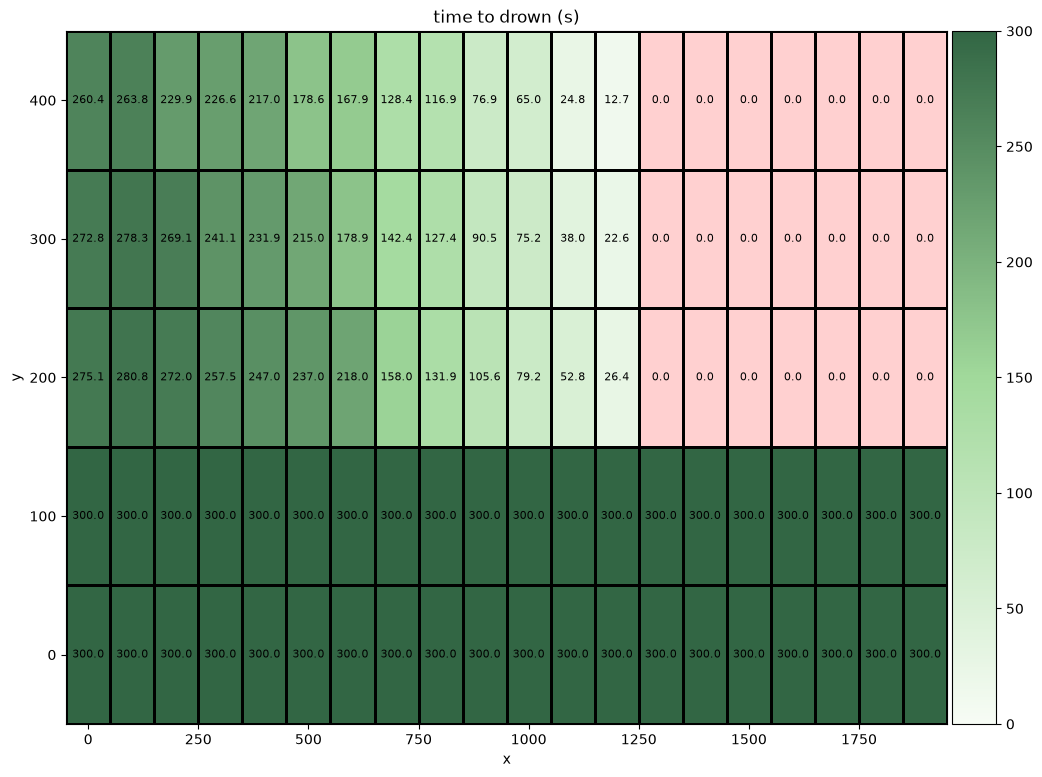

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Define your custom color list (Hex codes, RGB tuples, or named colors)
colors = ["#f7fcf5", "#a1d99b", "#326644"]
red = "#ffd0d0"

# 2. Create the smooth colormap gradient
custom_gradient = LinearSegmentedColormap.from_list("my_gradient", colors)


fig, ax = mc.show(properties={'flows.environment.c.survival_timer': {'cmap': custom_gradient, 'text': True},
                              'dead': {'color': red}},
                  figsize=(12,9), title="time to drown (s)", proplab='', legend_kwargs=False)

**Figure 6:** *A heat map of the amount of time a person has before drowning at the time of their rescue based on location,* **with UAS assistance.**

In [23]:
pdB2 = ParameterDomain(HazardParam)
pdB2.add_variables("victim_x", "victim_y",
                  lims={"victim_x": (0.0, 1900.0), "victim_y": (200.0, 400.0)})
pdB2.add_constant("distress_onset", 100.0)
pdB2.add_constant("with_aircraft", False)
pdB2(1,1)

HazardParam(victim_x=1.0, victim_y=1.0, distress_onset=100.0, with_aircraft=False)

In [24]:
psB2 = ParameterSample(pdB2)
psB2.add_variable_ranges(comb_kwargs={'resolutions': {'victim_x': 100.0,
                                                     'victim_y': 100.0}})
print(len(psB2.scenarios()), "scenarios")
psB2

60 scenarios


ParameterSample of scenarios:
 - rep0_range_0
 - rep0_range_1
 - rep0_range_2
 - rep0_range_3
 - rep0_range_4
 - rep0_range_5
 - rep0_range_6
 - rep0_range_7
 - rep0_range_8
 - rep0_range_9
 - ... (60 total)

In [25]:
resB2, histB2 = quiet(prop.parameter_sample, mdl, psB2, showprogress=False)
resB2

rep0_range_0.tend.classify.prob: 0.016666666666666666
rep0_range_0.tend.classify.rescued: False
rep0_range_0.tend.classify.rescue_time: nan
rep0_range_0.tend.cl                 nan
rep0_range_0.tend.cl                True
rep0_range_0.tend.cl         not_rescued
rep0_range_1.tend.classify.prob: 0.016666666666666666
rep0_range_1.tend.classify.rescued: False
rep0_range_1.tend.classify.rescue_time: nan
rep0_range_1.tend.cl                 nan
rep0_range_1.tend.cl                True
rep0_range_1.tend.cl         not_rescued
rep0_range_2.tend.classify.prob: 0.016666666666666666
rep0_range_2.tend.classify.rescued: False
rep0_range_2.tend.classify.rescue_time: nan
rep0_range_2.tend.cl                 nan
rep0_range_2.tend.cl                True
rep0_range_2.tend.cl         not_rescued
rep0_range_3.tend.classify.prob: 0.016666666666666666
rep0_range_3.tend.classify.rescued: False
rep0_range_3.tend.classify.rescue_time: nan
rep0_range_3.tend.cl                 nan
rep0_range_3.tend.cl          

In [26]:
last_survival2 = histB2.get_values('flows.environment.c.survival_timer',
                                 'flows.environment.c.distress_timer',
                                 'flows.environment.c.survival_rate',
                                 'flows.environment.c.dead').get_slice(-1)
last_survival2

rep0_range_0.flows.e           array(20)
rep0_range_1.flows.e           array(20)
rep0_range_2.flows.e           array(20)
rep0_range_3.flows.e           array(20)
rep0_range_4.flows.e           array(20)
rep0_range_5.flows.e           array(20)
rep0_range_6.flows.e           array(20)
rep0_range_7.flows.e           array(20)
rep0_range_8.flows.e           array(20)
rep0_range_9.flows.e           array(20)
rep0_range_10.flows.           array(20)
rep0_range_11.flows.           array(20)
rep0_range_12.flows.           array(20)
rep0_range_13.flows.           array(20)
rep0_range_14.flows.           array(20)
rep0_range_15.flows.           array(20)
rep0_range_16.flows.           array(20)
rep0_range_17.flows.           array(20)
rep0_range_18.flows.           array(20)
rep0_range_19.flows.           array(20)
rep0_range_20.flows.           array(20)
rep0_range_21.flows.           array(20)
rep0_range_22.flows.           array(20)
rep0_range_23.flows.           array(20)
rep0_range_24.fl

In [27]:
mc2 = MetricCoords(last_survival2, values=['flows.environment.c.survival_timer',
                                         'flows.environment.c.distress_timer',
                                         'flows.environment.c.survival_rate',
                                         'flows.environment.c.dead'],
                  metric=np.min,
                  p={'x_size': 20, 'y_size': 5, 'blocksize': 100.0})
mc2.dead = mc2.__dict__['flows.environment.c.survival_timer'] <= 0.0

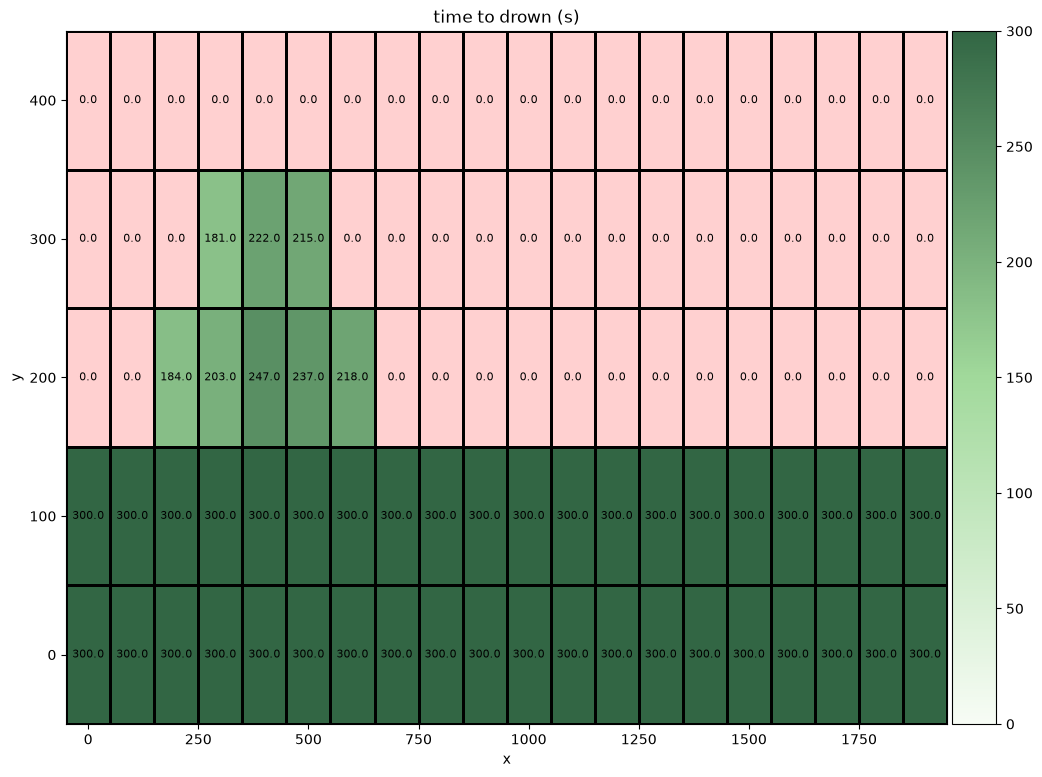

In [28]:
fig, ax = mc2.show(properties={'flows.environment.c.survival_timer': {'cmap': custom_gradient, 'text': True},
                              'dead': {'color': red}},
                  figsize=(12,9), title="time to drown (s)", proplab='', legend_kwargs=False)

**Figure 7:** *A heat map of the amount of time a person has before drowning at the time of their rescue based on location,* **without UAS assistance.** 

The areas where rescue is successful are concentrated close to the responder base, while distant areas are much more likely to not be reached in time before a swimmer in distress drowns.

## Conclusions

- The water rescue model showcases how fmdtools can be used to model the effectivity of drones across varying parameters in a complex beach environment:
- In our heat map graphs, the water area covered by UAS assistance increased 512% from the area without UAS assistance.
- Results from the heat map graphs suggest UAS assistance significantly increases rescue area coverage and probability of rescue on the beach.